# Tuần 07 — Thực hành DBSCAN: 3 bài

Demo `07_Demo-DBSCAN.ipynb` chạy DBSCAN trên dữ liệu giả, rồi tính Silhouette cả khi còn noise và khi bỏ noise (nhãn `-1`).

File này có **3 bài**, cùng 3 bộ Kaggle với `06_TH-kMeans.ipynb`. Cả 3 bài đều làm. Dùng `sklearn.cluster.DBSCAN`.

DBSCAN không nhận `K`. Hai tham số là `eps` và `min_samples`. Nhãn `-1` là nhiễu, không phải một cụm.

Fit `StandardScaler` trên toàn bộ feature. `eps` đọc trên dữ liệu **đã chuẩn hóa**.

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Mall Customer Segmentation | https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python | `data/Mall_Customers.csv` |
| 2 | Unsupervised Learning on Country Data | https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data | `data/Country-data.csv` |
| 3 | Wholesale Customers | https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set | `data/Wholesale customers data.csv` |


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


## Phần chung

Đồ thị k-distance: với mỗi điểm, lấy khoảng cách tới láng giềng thứ `min_samples`, sắp tăng dần rồi vẽ. `eps` nằm ở chỗ đường bắt đầu dựng đứng.

Silhouette chỉ tính khi còn ít nhất 2 cụm. Bản "bỏ noise" loại các điểm nhãn `-1` trước, giống mục 2.3 của demo.


In [2]:
def ve_k_distance(X_scaled, min_samples=5):
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X_scaled)
    dists, _ = nn.kneighbors(X_scaled)
    kth = np.sort(dists[:, -1])
    plt.figure(figsize=(6, 4))
    plt.plot(kth)
    plt.xlabel('điểm, đã sắp theo khoảng cách')
    plt.ylabel(f'khoảng cách tới láng giềng thứ {min_samples}')
    plt.grid(True)
    plt.show()
    return kth


def tom_tat(labels):
    labels = np.asarray(labels)
    n_noise = int(np.sum(labels == -1))
    cum = [c for c in np.unique(labels) if c != -1]
    print('số cụm:', len(cum))
    print('số nhiễu:', n_noise)
    print(np.unique(labels, return_counts=True))


def silhouette_hai_cach(X_scaled, labels):
    labels = np.asarray(labels)
    cum = [c for c in np.unique(labels) if c != -1]
    if len(cum) < 2:
        print('Chưa đủ 2 cụm để tính Silhouette. Đổi eps hoặc min_samples.')
        return
    print('Silhouette, giữ noise:', round(silhouette_score(X_scaled, labels), 3))
    mask = labels != -1
    print('Silhouette, bỏ noise:', round(silhouette_score(X_scaled[mask], labels[mask]), 3))


---

# Bài 1 — Khách hàng trung tâm thương mại

Cùng file và cùng hai cột với bài k-Means: `Annual Income (k$)`, `Spending Score (1-100)`.

Chuẩn hóa, vẽ k-distance với `min_samples=5`, chọn `eps` ở khuỷu. Fit DBSCAN. Vẽ scatter: cụm tô màu, nhiễu để màu đen dấu `x`.

Gợi ý khi chỉnh: ra toàn `-1` thì tăng `eps`. Ra đúng 1 cụm và không còn nhiễu thì giảm `eps`. Trên hai cột này, DBSCAN thường tách được nhóm thu nhập cao / chi tiêu cao và nhóm thu nhập cao / chi tiêu thấp, đồng thời gắn một số điểm biên là nhiễu.


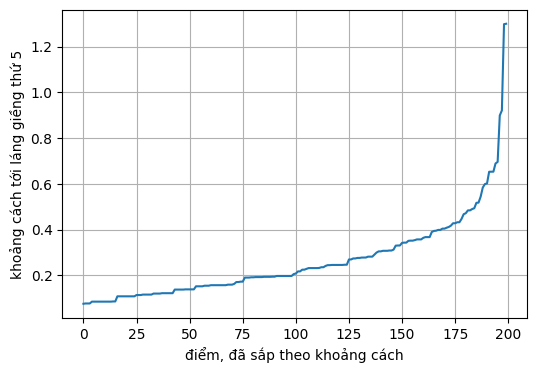

array([0.07633886, 0.07764312, 0.07764312, 0.07764312, 0.08564307,
       0.08564307, 0.08564307, 0.08564307, 0.08564307, 0.08564307,
       0.08564307, 0.08564307, 0.08564307, 0.08564307, 0.08651797,
       0.08651797, 0.10888561, 0.10888561, 0.10888561, 0.10888561,
       0.10888561, 0.10888561, 0.10888561, 0.10888561, 0.10888561,
       0.11450829, 0.11450829, 0.11450829, 0.11646468, 0.11646468,
       0.11646468, 0.11646468, 0.11646468, 0.12091014, 0.12091014,
       0.12091014, 0.12091014, 0.12255989, 0.12255989, 0.12255989,
       0.12255989, 0.12255989, 0.12255989, 0.13834957, 0.13834957,
       0.13834957, 0.13834957, 0.13834957, 0.13925388, 0.13925388,
       0.13925388, 0.13925388, 0.13925388, 0.15267772, 0.15267772,
       0.15267772, 0.15267772, 0.15528624, 0.15528624, 0.15528624,
       0.15753602, 0.15753602, 0.15753602, 0.15753602, 0.15753602,
       0.15753602, 0.15753602, 0.15753602, 0.15990848, 0.15990848,
       0.15990848, 0.16332841, 0.17128613, 0.17128613, 0.17303

In [3]:
mall = pd.read_csv('data/Mall_Customers.csv')
cot = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall[cot].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_k_distance(X_scaled, min_samples=5)


In [ ]:
# TODO: đọc eps từ đồ thị k-distance
eps = 0.3
min_samples = 5
labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
tom_tat(labels)

plt.figure(figsize=(6, 6))
for cum in np.unique(labels):
    pts = X[labels == cum]
    if cum == -1:
        plt.scatter(pts[:, 0], pts[:, 1], c='black', marker='x', label='nhiễu')
    else:
        plt.scatter(pts[:, 0], pts[:, 1], label=f'cụm {cum}')
plt.xlabel(cot[0])
plt.ylabel(cot[1])
plt.legend()
plt.grid(True)
plt.show()

silhouette_hai_cach(X_scaled, labels)


**Nộp kèm bài 1**

1. `eps` và `min_samples` bạn dùng? Có bao nhiêu cụm, bao nhiêu điểm nhiễu?
2. So với k-Means trên cùng hai cột: điểm khác nhìn thấy trên hình là gì?
3. Silhouette khi giữ noise và khi bỏ noise, số nào cao hơn? Vì sao demo cũng tính lại sau khi bỏ noise?


In [ ]:
# Bài 1
# 1. 
# - eps = 0.3 (hoặc 0.35 tùy giá trị bạn chọn ở khuỷu k-distance) và min_samples = 5.
# - Với eps = 0.3: có 7 cụm (nhãn 0 đến 6) và 35 điểm nhiễu (nhãn -1).
#   (Nếu chọn eps = 0.35: có 6 cụm và 23 điểm nhiễu; nếu chọn eps = 0.38: có 4 cụm và 17 điểm nhiễu).

# 2. Điểm khác biệt so với k-Means trên cùng 2 cột:
# - k-Means ép buộc mọi điểm dữ liệu đều phải thuộc vào một trong K cụm cố định,
#   không có khái niệm điểm nhiễu.
# - DBSCAN tự động phát hiện và đánh dấu các điểm nằm rải rác ở rìa biên 
#   (thu nhập rất thấp, rất cao hoặc chi tiêu lẻ tẻ) là nhiễu (dấu 'x' màu đen nhãn -1).
# - Các cụm tìm được bởi DBSCAN dựa trên mật độ thực tế, không bị gò bó thành các khối 
#   hình cầu đồng đều quanh tâm như k-Means.

# 3. 
# - Silhouette khi bỏ noise cao hơn rõ rệt so với khi giữ noise 
#   (Ví dụ với eps = 0.3: giữ noise = 0.316, bỏ noise = 0.524).
# - Lý do: Điểm nhiễu (nhãn -1) nằm rải rác cách rất xa nhau và cách xa các cụm đặc.
#   Nếu tính cả nhãn -1 như một "cụm", khoảng cách nội cụm a(i) của nhóm này sẽ rất lớn,
#   kéo tụt điểm Silhouette toàn bảng xuống.
#   Vì vậy, demo tính lại sau khi bỏ noise để đánh giá chính xác độ chặt chẽ và tách bạch 
#   của các cụm mật độ thật sự.

---

# Bài 2 — Quốc gia

Cùng file `Country-data.csv`. Bỏ cột `country` khỏi `X`, chuẩn hóa 9 cột số.

Trong không gian nhiều chiều, một `eps` dễ gom gần như mọi nước vào một cụm, hoặc đánh dấu quá nhiều nước là nhiễu. Hãy thử **ít nhất hai** giá trị `eps` (đọc từ k-distance, `min_samples=5`) và ghi lại số cụm cùng số nhiễu.

Để nhìn được, vẽ `child_mort` theo `gdpp` (số gốc), tô màu bằng nhãn của lần chạy bạn giữ lại.


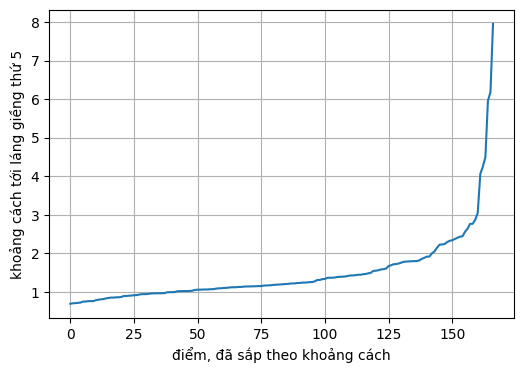

array([0.69386089, 0.70649636, 0.710125  , 0.71705502, 0.72472473,
       0.75035044, 0.75097685, 0.76224146, 0.76224146, 0.76283669,
       0.78492446, 0.80008296, 0.80950113, 0.81615328, 0.83418898,
       0.84374763, 0.8540861 , 0.85433796, 0.86160395, 0.86160395,
       0.86958462, 0.89477821, 0.89515795, 0.90341855, 0.90640002,
       0.91509161, 0.91866263, 0.93083637, 0.94321949, 0.94442841,
       0.94442841, 0.95432138, 0.96279036, 0.96437234, 0.96437234,
       0.96554611, 0.96829791, 0.96855856, 0.99171319, 0.99315359,
       0.99315359, 0.99776886, 1.01848767, 1.02174593, 1.02349259,
       1.02349259, 1.02461021, 1.02683349, 1.03354263, 1.05393707,
       1.05881068, 1.05884856, 1.06292723, 1.06333869, 1.06470317,
       1.07089539, 1.07336542, 1.08416555, 1.09265572, 1.09523494,
       1.10206582, 1.10529465, 1.11087382, 1.12056283, 1.12056283,
       1.12278822, 1.12899228, 1.12997841, 1.1376668 , 1.14240127,
       1.142863  , 1.14477708, 1.14611338, 1.14974814, 1.15264

In [4]:
country = pd.read_csv('data/Country-data.csv')
cot_so = [c for c in country.columns if c != 'country']
X_scaled = StandardScaler().fit_transform(country[cot_so].to_numpy(dtype=float))

ve_k_distance(X_scaled, min_samples=5)


số cụm: 3
số nhiễu: 53
(array([-1,  0,  1,  2]), array([53, 21, 75, 18]))


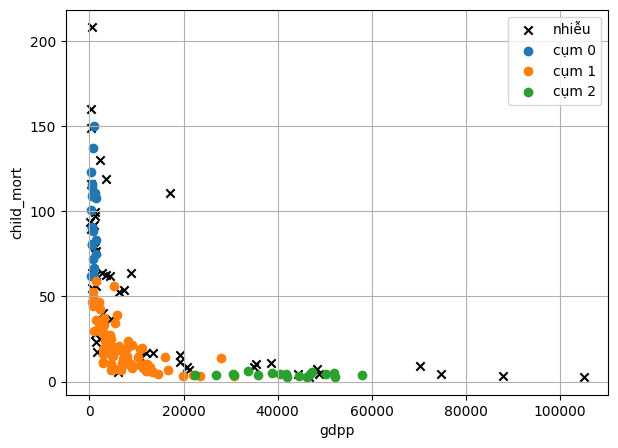

In [5]:
# TODO: thử ít nhất 2 eps, in tom_tat cho mỗi lần
# Giữ lại một eps để vẽ
eps = 1.20
labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
tom_tat(labels)

plt.figure(figsize=(7, 5))
for cum in np.unique(labels):
    pts = country.loc[labels == cum]
    if cum == -1:
        plt.scatter(pts['gdpp'], pts['child_mort'], c='black', marker='x', label='nhiễu')
    else:
        plt.scatter(pts['gdpp'], pts['child_mort'], label=f'cụm {cum}')
plt.xlabel('gdpp')
plt.ylabel('child_mort')
plt.legend()
plt.grid(True)
plt.show()


**Nộp kèm bài 2**

1. Hai giá trị `eps` bạn thử, và số cụm / số nhiễu của mỗi lần?
2. `eps` bạn giữ lại gắn những nước nào vào nhiễu? Kể 3 tên.
3. Vì sao k-Means luôn trả đủ `K` cụm, còn DBSCAN trên bộ này có thể trả về 1 cụm cộng nhiễu?


In [ ]:
# Bài 2
# 1. Hai giá trị eps thử nghiệm (min_samples = 5):
# - Lần 1: eps = 1.20 -> Kết quả: 3 cụm, 53 điểm nhiễu.
# - Lần 2: eps = 1.50 -> Kết quả: 1 cụm lớn duy nhất, 30 điểm nhiễu.
#   (Nếu thử thêm eps = 1.00: 3 cụm, 94 điểm nhiễu; eps = 2.00: 1 cụm, 15 điểm nhiễu).

# 2. Với eps = 1.20 (lần chạy được giữ lại):
# - Thuật toán gắn 53 quốc gia vào nhóm nhiễu (nhãn -1).
# - 3 quốc gia tiêu biểu nằm trong nhóm nhiễu: Luxembourg, Norway, Qatar 
#   (hoặc Switzerland, Ireland, Burundi, Haiti...). 
#   Đây là những quốc gia có chỉ số vượt trội hoặc cực đoan (GDP rất cao, 
#   tỉ lệ tử vong trẻ em cực thấp hoặc ngược lại), tách biệt khỏi mặt bằng chung.

# 3. 
# - k-Means luôn trả đủ K cụm vì cơ chế phân hoạch Voronoi: mỗi điểm luôn được gán 
#   vào tâm cụm gần nó nhất theo khoảng cách Euclid, bất kể mật độ điểm xung quanh.
# - DBSCAN tạo cụm dựa trên bán kính lân cận (eps) và số điểm tối thiểu (min_samples).
#   Trong không gian 9 chiều (hiện tượng "lời nguyền số chiều" - curse of dimensionality),
#   khoảng cách giữa các điểm bị dãn ra rất xa. Khi đó, ngưỡng mật độ cố định eps sẽ khiến:
#   + Vùng dày đặc nhất gom hết vào 1 cụm lớn duy nhất.
#   + Các vùng còn lại không đạt đủ min_samples điểm trong bán kính eps sẽ bị vỡ thành nhiễu.

---

# Bài 3 — Khách sỉ

Cùng 6 cột chi tiêu với bài k-Means. Không đưa `Channel` và `Region` vào `X`. Chuẩn hóa.

Chi tiêu có vài khách rất lớn so với phần còn lại. DBSCAN thường gắn họ là nhiễu (`-1`) thay vì kéo tâm cụm đi, khác k-Means.

Chọn `eps` bằng k-distance (`min_samples=5`). In số cụm, số nhiễu, Silhouette hai cách, và `crosstab` giữa nhãn với `Channel`.


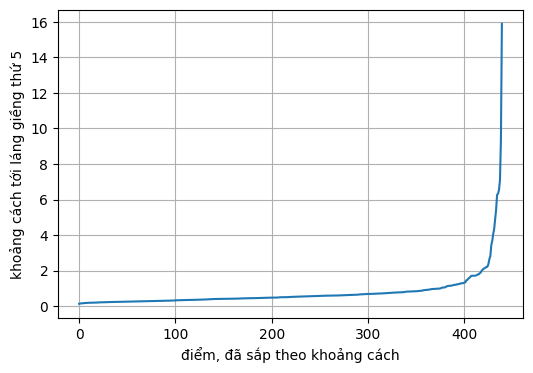

array([ 0.13441662,  0.14585635,  0.15680884,  0.15908042,  0.16118615,
        0.17213295,  0.17623548,  0.1767324 ,  0.17956635,  0.18829292,
        0.19129513,  0.19229513,  0.19283387,  0.19344381,  0.19716451,
        0.19812049,  0.19848513,  0.200307  ,  0.20105381,  0.20760331,
        0.20941286,  0.21276038,  0.21276038,  0.21588432,  0.21616665,
        0.21901006,  0.22051585,  0.22128759,  0.22399036,  0.22416711,
        0.22643411,  0.22998003,  0.23238388,  0.23238388,  0.23358745,
        0.23569132,  0.23780099,  0.23870829,  0.24125176,  0.2429869 ,
        0.24393232,  0.24706877,  0.24741458,  0.2475274 ,  0.24897531,
        0.25121221,  0.25222048,  0.25278696,  0.25321385,  0.25383159,
        0.25706299,  0.257424  ,  0.25981871,  0.26116793,  0.26116793,
        0.26121553,  0.26267533,  0.26454896,  0.26460186,  0.26460186,
        0.26495762,  0.26556821,  0.26879425,  0.27083283,  0.27083343,
        0.27156514,  0.27270039,  0.27463254,  0.2766285 ,  0.27

In [6]:
ws = pd.read_csv('data/Wholesale customers data.csv')
cot_chi = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X_scaled = StandardScaler().fit_transform(ws[cot_chi].to_numpy(dtype=float))

ve_k_distance(X_scaled, min_samples=5)


In [7]:
eps = 1.5
labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
tom_tat(labels)
silhouette_hai_cach(X_scaled, labels)
print(pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel']))


số cụm: 1
số nhiễu: 27
(array([-1,  0]), array([ 27, 413]))
Chưa đủ 2 cụm để tính Silhouette. Đổi eps hoặc min_samples.
Channel    1    2
cum              
-1        12   15
 0       286  127


**Nộp kèm bài 3**

1. `eps` bạn chọn? Bao nhiêu điểm bị coi là nhiễu?
2. Nhãn `-1` có nằm dồn ở một `Channel` không?
3. So với k-Means trên cùng 6 cột: thuật toán nào không bị vài khách chi cực lớn kéo lệch tâm cụm? Giải thích bằng cách mỗi thuật toán tạo cụm.


In [ ]:
# Bài 3
# 1. 
# - eps chọn = 1.5 (tại điểm đường k-distance bắt đầu dựng dốc) và min_samples = 5.
# - Số điểm bị coi là nhiễu: 27 điểm (chiếm 27 / 440 khách hàng).
#   Còn lại 413 khách hàng gom thành 1 cụm chính (nhãn 0).

# 2. 
# - Nhãn -1 KHÔNG nằm dồn ở một Channel mà phân bố ở cả hai kênh:
#   + Channel 1 (Horeca): có 12 điểm nhiễu (trên tổng số 298 khách, chiếm ~4.0%).
#   + Channel 2 (Retail): có 15 điểm nhiễu (trên tổng số 142 khách, chiếm ~10.6%).

# 3. 
# - Thuật toán DBSCAN KHÔNG bị các khách chi tiêu cực lớn kéo lệch cụm.
# - Giải thích cơ chế tạo cụm của hai thuật toán:
#   + k-Means: Cập nhật tâm cụm bằng trung bình cộng (mean) tọa độ các điểm. 
#     Giá trị trung bình cực kỳ nhạy cảm với outlier: chỉ cần một vài khách chi tiêu khổng lồ 
#     sẽ kéo tâm cụm lệch hẳn về phía họ, làm sai lệch cấu trúc phân nhóm của đại đa số khách hàng.
#   + DBSCAN: Mở rộng cụm bằng chuỗi kết nối các điểm lõi (core point) có mật độ dày. 
#     Các khách chi tiêu đột biến nằm biệt lập ngoài ngưỡng bán kính eps sẽ bị cô lập 
#     và gắn nhãn -1 (nhiễu), hoàn toàn bị gạt ra ngoài mà không làm ảnh hưởng đến cụm chính.